In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3
from atmo3 import atm_utils as au

import xarray as xr
import pandas as pd

from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [2]:
time_utc = datetime(2023, 9, 22, 18, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================
atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'
# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

# 1. Target time t0
t0 = pd.Timestamp(time_utc).replace(tzinfo=None)

# 2. Values for delta_t (in minutes) to evaluate
delta_t_values = np.arange(1, 300, 1, dtype=int)  # 10 values from 1 to 30 minutes

# Find the maximum delta_t to read from the file just once to save I/O time
max_delta_t = max(delta_t_values)
t_start_max = t0 - pd.Timedelta(minutes=max_delta_t)
t_end_max = t0 + pd.Timedelta(minutes=max_delta_t)

# 3. Read the APEX data for the largest time window needed
chunks = []
for chunk in pd.read_csv(
    apexfile,
    header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'],
    chunksize=1024
):
    chunk_filtered = chunk[(chunk['UT'] >= t_start_max) & (chunk['UT'] <= t_end_max)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)

full_window_data = pd.concat(chunks) if chunks else pd.DataFrame(
    columns=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed']
)

# Convert APEX temperature from Celsius to Kelvin
if not full_window_data.empty:
    full_window_data['Temperature'] += 273.15

results = []

# 4. Loop over each delta_t to compute parameters for a 2*delta_t window
for dt in delta_t_values:
    t_start = t0 - pd.Timedelta(minutes=dt)
    t_end   = t0 + pd.Timedelta(minutes=dt)
    
    # Filter data specific to this window size
    mask = (full_window_data['UT'] >= t_start) & (full_window_data['UT'] <= t_end)
    window_data = full_window_data[mask]
    
    if not window_data.empty:
        pwv_mean = window_data['PWV'].mean()
        sigma_pwv = window_data['PWV'].std()
        t_mean = window_data['Temperature'].mean()
        sigma_t = window_data['Temperature'].std()
    else:
        pwv_mean = sigma_pwv = t_mean = sigma_t = float('nan')
        
    results.append({
        'delta_t (min)': dt,
        'window (min)': 2 * dt,
        'PWV_mean': pwv_mean,
        'sigma_PWV': sigma_pwv,
        'T_mean': t_mean,
        'sigma_T': sigma_t
    })

# 6. Plotting the results
results_df = pd.DataFrame(results)



In [3]:
import numpy as np
import pandas as pd
from datetime import datetime, timezone

def analyze_apex_period_optimized(target_time, full_data, delta_t_values):
    """
    Computes statistics using NumPy arrays to avoid Pandas loop overhead.
    Assumes full_data is already pre-loaded into memory and pre-filtered.
    """
    t0 = pd.Timestamp(target_time).replace(tzinfo=None)
    
    # 1. Convert to numpy for fast array operations
    # Calculate absolute time diff in minutes from t0 for every row
    time_diffs_min = np.abs((full_data['UT'] - t0).dt.total_seconds() / 60.0).values
    pwv_array = full_data['PWV'].values
    temp_array = full_data['Temperature'].values
    
    results = []
    
    # 2. Loop over delta_t using NumPy masking
    for dt in delta_t_values:
        mask = time_diffs_min <= dt
        
        if np.any(mask):
            valid_pwv = pwv_array[mask]
            valid_temp = temp_array[mask]
            
            results.append({
                'target_time': target_time,
                'delta_t (min)': dt,
                'window (min)': 2 * dt,
                'PWV_mean': np.nanmean(valid_pwv),
                'sigma_PWV': np.nanstd(valid_pwv, ddof=1),
                'T_mean': np.nanmean(valid_temp),
                'sigma_T': np.nanstd(valid_temp, ddof=1)
            })
        else:
            results.append({
                'target_time': target_time, 'delta_t (min)': dt, 'window (min)': 2 * dt,
                'PWV_mean': np.nan, 'sigma_PWV': np.nan, 'T_mean': np.nan, 'sigma_T': np.nan
            })
            
    return pd.DataFrame(results)

# =====================================================================
# Main execution script
# =====================================================================

target_times = [
    # Summer (Chile summer time, UTC-3)
    datetime(2024, 2, 23, 6, 0, tzinfo=timezone.utc),   # summer night -> 03:00 local
    datetime(2024, 2, 23, 18, 0, tzinfo=timezone.utc),  # summer day   -> 15:00 local

    # Autumn (Chile standard time, UTC-4)
    datetime(2023, 4, 15, 7, 0, tzinfo=timezone.utc),   # autumn night -> 03:00 local
    datetime(2023, 4, 15, 19, 0, tzinfo=timezone.utc),  # autumn day   -> 15:00 local

    # Winter (Chile standard time, UTC-4)
    datetime(2023, 7, 15, 7, 0, tzinfo=timezone.utc),   # winter night -> 03:00 local
    datetime(2023, 7, 15, 19, 0, tzinfo=timezone.utc),  # winter day   -> 15:00 local

    # Spring (Chile summer time, UTC-3)
    datetime(2023, 10, 15, 6, 0, tzinfo=timezone.utc),  # spring night -> 03:00 local
    datetime(2023, 10, 15, 18, 0, tzinfo=timezone.utc), # spring day   -> 15:00 local
]

delta_t_values = np.arange(1, 300, 1, dtype=int)

# 1. Read I/O exactly ONCE
max_dt = max(delta_t_values)
t_min_global = min(target_times).replace(tzinfo=None) - pd.Timedelta(minutes=max_dt)
t_max_global = max(target_times).replace(tzinfo=None) + pd.Timedelta(minutes=max_dt)

print("Loading dataset from disk...")
chunks = []
for chunk in pd.read_csv(
    apexfile, header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'], chunksize=50000 
):
    chunk_filtered = chunk[(chunk['UT'] >= t_min_global) & (chunk['UT'] <= t_max_global)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)

master_data = pd.concat(chunks) if chunks else pd.DataFrame(columns=['UT', 'PWV', 'Temperature'])

if not master_data.empty:
    master_data['Temperature'] += 273.15  # Convert Celsius to Kelvin

# 2. Iterate dynamically over target_times in memory
all_results = []
for t in target_times:
    print(f"Analyzing period: {t}")
    res_df = analyze_apex_period_optimized(t, master_data, delta_t_values)
    all_results.append(res_df)

combined_results_df = pd.concat(all_results, ignore_index=True)
print("Finished analysis!")

Loading dataset from disk...
Analyzing period: 2024-02-23 06:00:00+00:00
Analyzing period: 2024-02-23 18:00:00+00:00


/tmp/ipykernel_774671/1639178803.py:32: RuntimeWarning: Mean of empty slice
  'PWV_mean': np.nanmean(valid_pwv),
/pscratch/sd/v/valer/cmbenv/master-0.0.1/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Analyzing period: 2023-04-15 07:00:00+00:00
Analyzing period: 2023-04-15 19:00:00+00:00
Analyzing period: 2023-07-15 07:00:00+00:00
Analyzing period: 2023-07-15 19:00:00+00:00
Analyzing period: 2023-10-15 06:00:00+00:00
Analyzing period: 2023-10-15 18:00:00+00:00
Finished analysis!


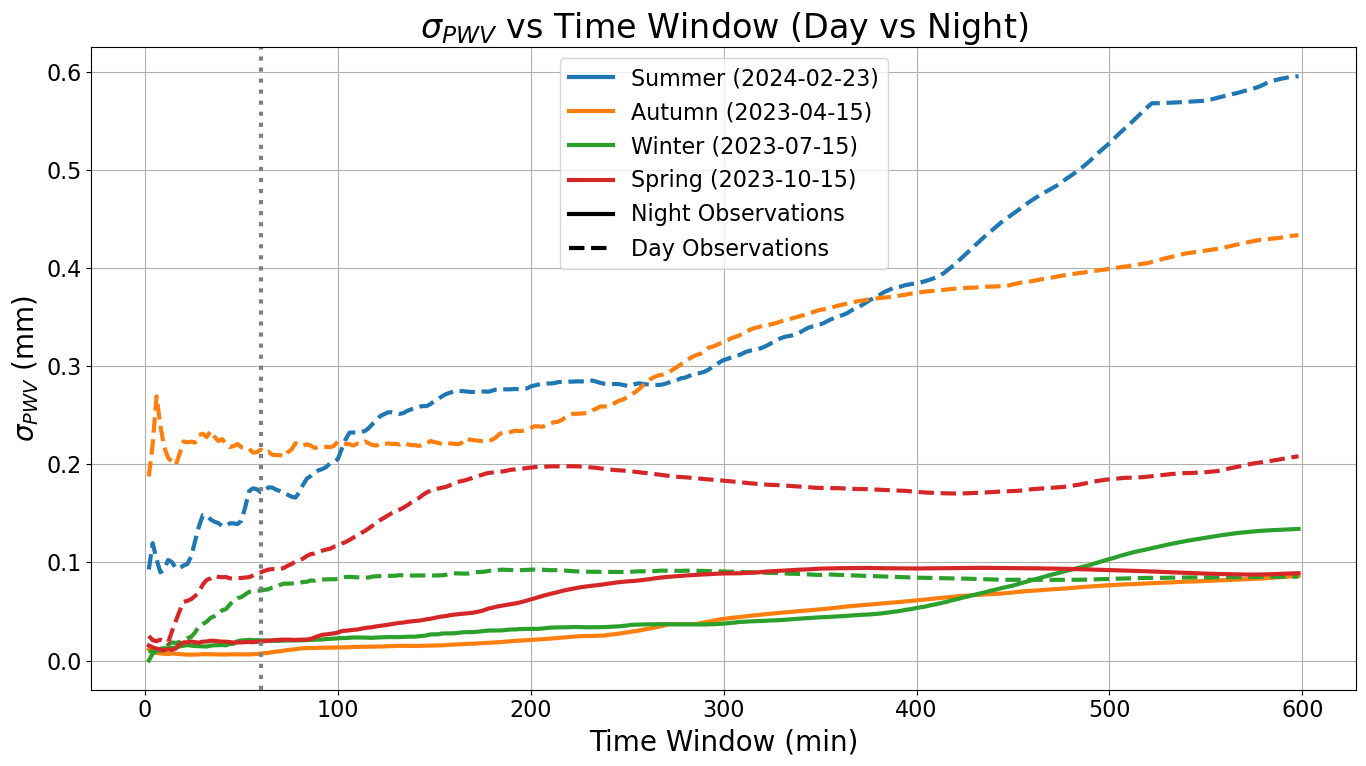

In [4]:
# Dictionary mapping user-friendly names to specific target_times
period_names = {
    'summer_night': datetime(2024, 2, 23, 6, 0, tzinfo=timezone.utc),
    'summer_day': datetime(2024, 2, 23, 18, 0, tzinfo=timezone.utc),
    'autumn_night': datetime(2023, 4, 15, 7, 0, tzinfo=timezone.utc),
    'autumn_day': datetime(2023, 4, 15, 19, 0, tzinfo=timezone.utc),
    'winter_night': datetime(2023, 7, 15, 7, 0, tzinfo=timezone.utc),
    'winter_day': datetime(2023, 7, 15, 19, 0, tzinfo=timezone.utc),
    'spring_night': datetime(2023, 10, 15, 6, 0, tzinfo=timezone.utc),
    'spring_day': datetime(2023, 10, 15, 18, 0, tzinfo=timezone.utc)
}

# Retrieve data for each period and store in a dictionary
results_by_period = {}
for name, target_t in period_names.items():
    results_by_period[name] = combined_results_df[combined_results_df['target_time'] == target_t]

# Dynamically assign to individual variables as requested (e.g. summer_day_results)
globals().update({f"{name}_results": df for name, df in results_by_period.items()})

# --- Plotting ---
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(14, 8))
seasons = ['summer', 'autumn', 'winter', 'spring']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
legend_handles = []

for i, season in enumerate(seasons):
    color = colors[i]
    
    # Plot Day (Dashed)
    name_day = f"{season}_day"
    df_day = results_by_period[name_day]
    # No label added here to avoid duplicates in legend
    ax.plot(df_day['window (min)'], df_day['sigma_PWV'], color=color, linestyle='--', linewidth=3)
    
    # Plot Night (Solid)
    name_night = f"{season}_night"
    df_night = results_by_period[name_night]
    ax.plot(df_night['window (min)'], df_night['sigma_PWV'], color=color, linestyle='-', linewidth=3)
    
    # Add season + date to custom legend
    target_date = period_names[name_day].strftime('%Y-%m-%d')
    legend_handles.append(mlines.Line2D([], [], color=color, linewidth=3, label=f"{season.title()} ({target_date})"))

# Add Day/Night styling to custom legend
legend_handles.append(mlines.Line2D([], [], color='k', linestyle='-', linewidth=3, label='Night Observations'))
legend_handles.append(mlines.Line2D([], [], color='k', linestyle='--', linewidth=3, label='Day Observations'))

ax.axvline(60, color='gray', linestyle=':', linewidth=3)  # Vertical line at 60 minutes

ax.set_title(r"$\sigma_{PWV}$ vs Time Window (Day vs Night)")
ax.set_xlabel("Time Window (min)")
ax.set_ylabel(r"$\sigma_{PWV}$ (mm)")
ax.legend(handles=legend_handles)
ax.grid(True)

plt.tight_layout()
plt.show()

In [5]:
print(results_by_period['summer_night'].head())

                target_time  delta_t (min)  window (min)  PWV_mean  sigma_PWV  \
0 2024-02-23 06:00:00+00:00              1             2       NaN        NaN   
1 2024-02-23 06:00:00+00:00              2             4       NaN        NaN   
2 2024-02-23 06:00:00+00:00              3             6       NaN        NaN   
3 2024-02-23 06:00:00+00:00              4             8       NaN        NaN   
4 2024-02-23 06:00:00+00:00              5            10       NaN        NaN   

       T_mean   sigma_T  
0  267.716667  0.152753  
1  267.690000  0.240832  
2  267.707143  0.207020  
3  267.727778  0.185592  
4  267.750000  0.178885  


In [6]:
# 1. Define periods to span from 2007 to 2025
years = range(2007, 2026)

# Template of month, day, hour, minute corresponding to each period
template_times = {
    'summer_night': (2, 23, 6, 0),
    'summer_day':   (2, 23, 18, 0),
    'autumn_night': (4, 15, 7, 0),
    'autumn_day':   (4, 15, 19, 0),
    'winter_night': (7, 15, 7, 0),
    'winter_day':   (7, 15, 19, 0),
    'spring_night': (10, 15, 6, 0),
    'spring_day':   (10, 15, 18, 0)
}

all_targets = []
for y in years:
    for name, (mo, d, h, m) in template_times.items():
        all_targets.append((name, datetime(y, mo, d, h, m, tzinfo=timezone.utc)))

delta_t_values = np.arange(1, 300, 1, dtype=int)
max_dt = max(delta_t_values)

# 2. Read multi-year data dynamically within the required minimum and maximum target limits
t_min_global = min(dt for _, dt in all_targets).replace(tzinfo=None) - pd.Timedelta(minutes=max_dt)
t_max_global = max(dt for _, dt in all_targets).replace(tzinfo=None) + pd.Timedelta(minutes=max_dt)

print("Loading multi-year dataset from disk (2007-2025)...")
chunks = []
for chunk in pd.read_csv(
    apexfile, header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'], chunksize=50000 
):
    chunk_filtered = chunk[(chunk['UT'] >= t_min_global) & (chunk['UT'] <= t_max_global)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)

master_data_my = pd.concat(chunks) if chunks else pd.DataFrame(columns=['UT', 'PWV', 'Temperature'])
if not master_data_my.empty:
    master_data_my['Temperature'] += 273.15

# 3. Process all the targets using our optimized NumPy function
print(f"Analyzing {len(all_targets)} total periods...")
all_multi_results = []
for period_name, target_t in all_targets:
    res_df = analyze_apex_period_optimized(target_t, master_data_my, delta_t_values)
    res_df['period_name'] = period_name
    res_df['year'] = target_t.year
    all_multi_results.append(res_df)

multiyear_df = pd.concat(all_multi_results, ignore_index=True)


Loading multi-year dataset from disk (2007-2025)...
Analyzing 152 total periods...


/tmp/ipykernel_774671/1639178803.py:32: RuntimeWarning: Mean of empty slice
  'PWV_mean': np.nanmean(valid_pwv),
/pscratch/sd/v/valer/cmbenv/master-0.0.1/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_774671/1639178803.py:32: RuntimeWarning: Mean of empty slice
  'PWV_mean': np.nanmean(valid_pwv),
/pscratch/sd/v/valer/cmbenv/master-0.0.1/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_774671/1639178803.py:32: RuntimeWarning: Mean of empty slice
  'PWV_mean': np.nanmean(valid_pwv),
/pscratch/sd/v/valer/cmbenv/master-0.0.1/conda/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, 

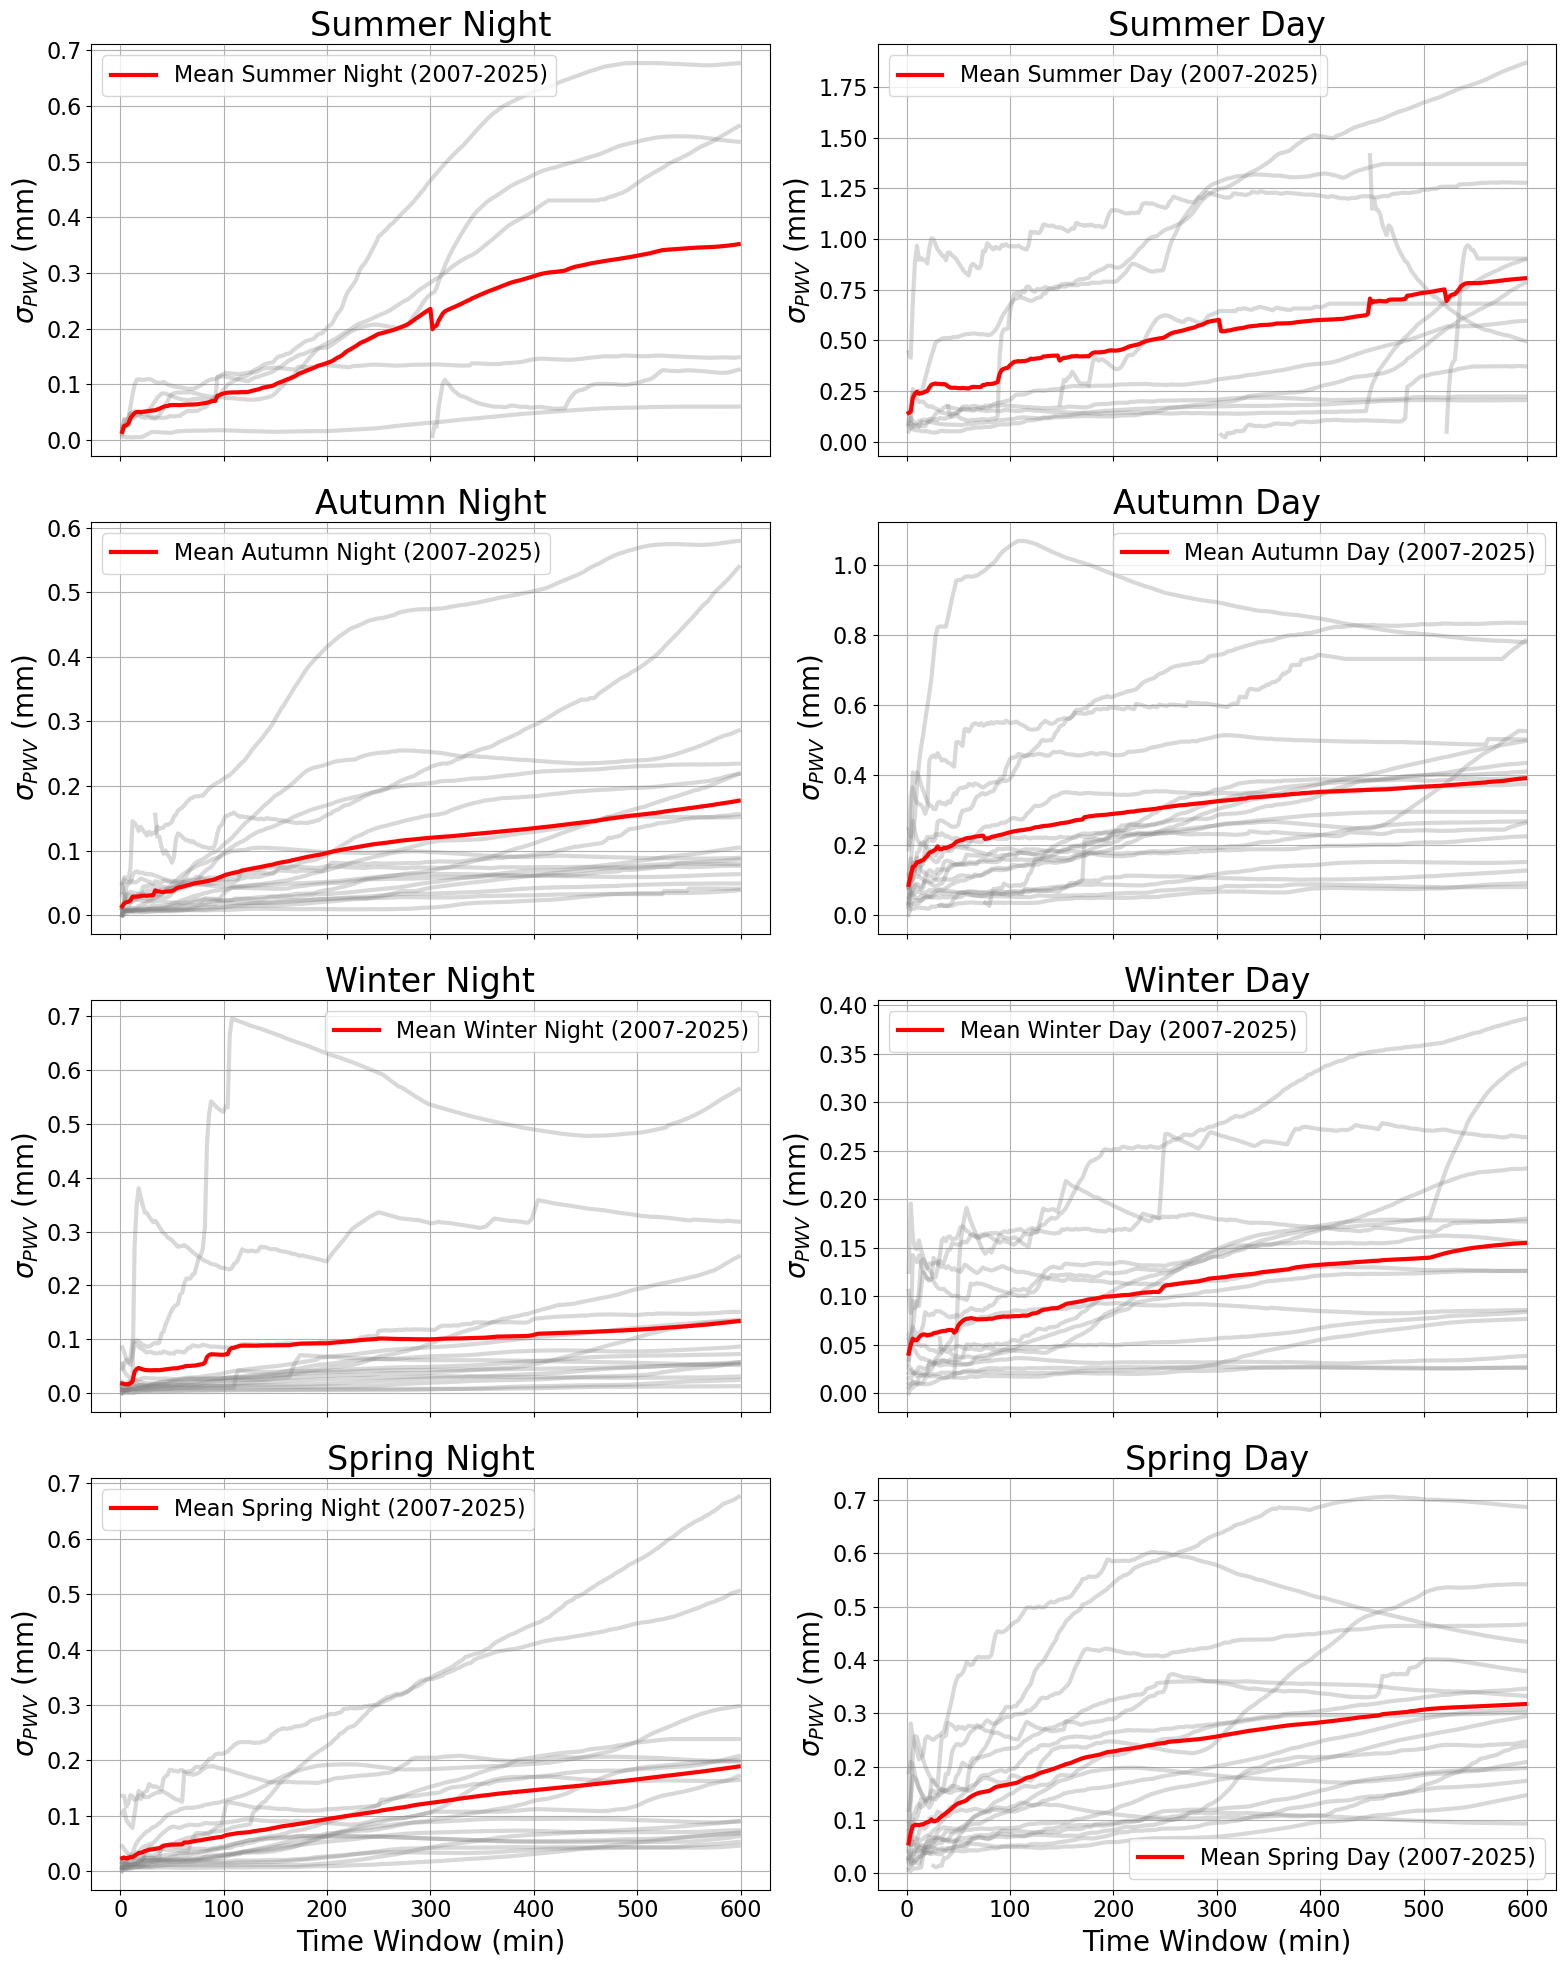

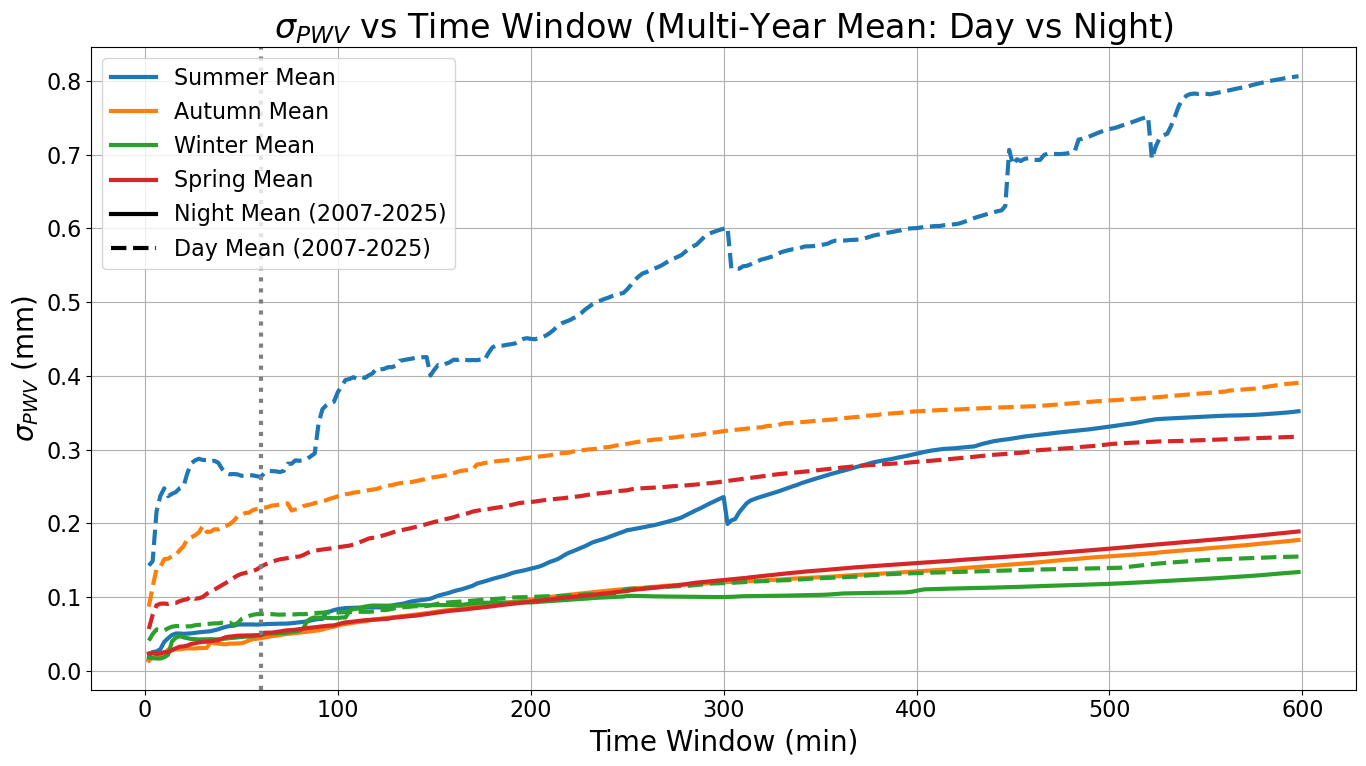

In [7]:
# 4. Filter, mean, and multi-year plotting (8 individual panels)
mean_results_by_period = {}

fig, axes = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes = axes.flatten()

for idx, (period_name, _) in enumerate(template_times.items()):
    ax = axes[idx]
    df_period = multiyear_df[multiyear_df['period_name'] == period_name]
    
    # Plot individual years silently (gray, no legend)
    for y in years:
        df_year = df_period[df_period['year'] == y]
        if not df_year.empty:
            ax.plot(df_year['window (min)'], df_year['sigma_PWV'], color='gray', alpha=0.3)
            
    # Calculate the mean across all years for each time window
    # Include all required metrics in the groupby
    mean_df = df_period.groupby('window (min)')[['sigma_PWV', 'PWV_mean', 'sigma_T', 'T_mean']].mean().reset_index()
    # Store this mean dataset to use later
    mean_results_by_period[period_name] = mean_df
    
    # Plot the consolidated mean (highlighted with legend)
    label_name = f"Mean {period_name.replace('_', ' ').title()} (2007-2025)"
    ax.plot(mean_df['window (min)'], mean_df['sigma_PWV'], color='red', linewidth=3, label=label_name)
    
    ax.set_title(f"{period_name.replace('_', ' ').title()}")
    ax.set_ylabel(r"$\sigma_{PWV}$ (mm)")
    if idx >= 6:
        ax.set_xlabel("Time Window (min)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# 5. Cell 4 Equivalent: Recreate the Season Summary Graph using the stored multi-year Means
import matplotlib.lines as mlines

fig2, ax2 = plt.subplots(figsize=(14, 8))
seasons = ['summer', 'autumn', 'winter', 'spring']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
legend_handles2 = []

for i, season in enumerate(seasons):
    color = colors[i]
    
    # Plot Day Multi-Year Means (Dashed)
    name_day = f"{season}_day"
    mean_df_day = mean_results_by_period[name_day]
    ax2.plot(mean_df_day['window (min)'], mean_df_day['sigma_PWV'], color=color, linestyle='--', linewidth=3)
    
    # Plot Night Multi-Year Means (Solid)
    name_night = f"{season}_night"
    mean_df_night = mean_results_by_period[name_night]
    ax2.plot(mean_df_night['window (min)'], mean_df_night['sigma_PWV'], color=color, linestyle='-', linewidth=3)
    
    # Add season to custom legend
    legend_handles2.append(mlines.Line2D([], [], color=color, linewidth=3, label=f"{season.title()} Mean"))

# Add Day/Night styling to custom legend
legend_handles2.append(mlines.Line2D([], [], color='k', linestyle='-', linewidth=3, label='Night Mean (2007-2025)'))
legend_handles2.append(mlines.Line2D([], [], color='k', linestyle='--', linewidth=3, label='Day Mean (2007-2025)'))
ax2.axvline(60, color='gray', linestyle=':', linewidth=3)  # Vertical line at 60 minutes

ax2.set_title(r"$\sigma_{PWV}$ vs Time Window (Multi-Year Mean: Day vs Night)")
ax2.set_xlabel("Time Window (min)")
ax2.set_ylabel(r"$\sigma_{PWV}$ (mm)")
ax2.legend(handles=legend_handles2)
ax2.grid(True)

plt.tight_layout()
plt.show()

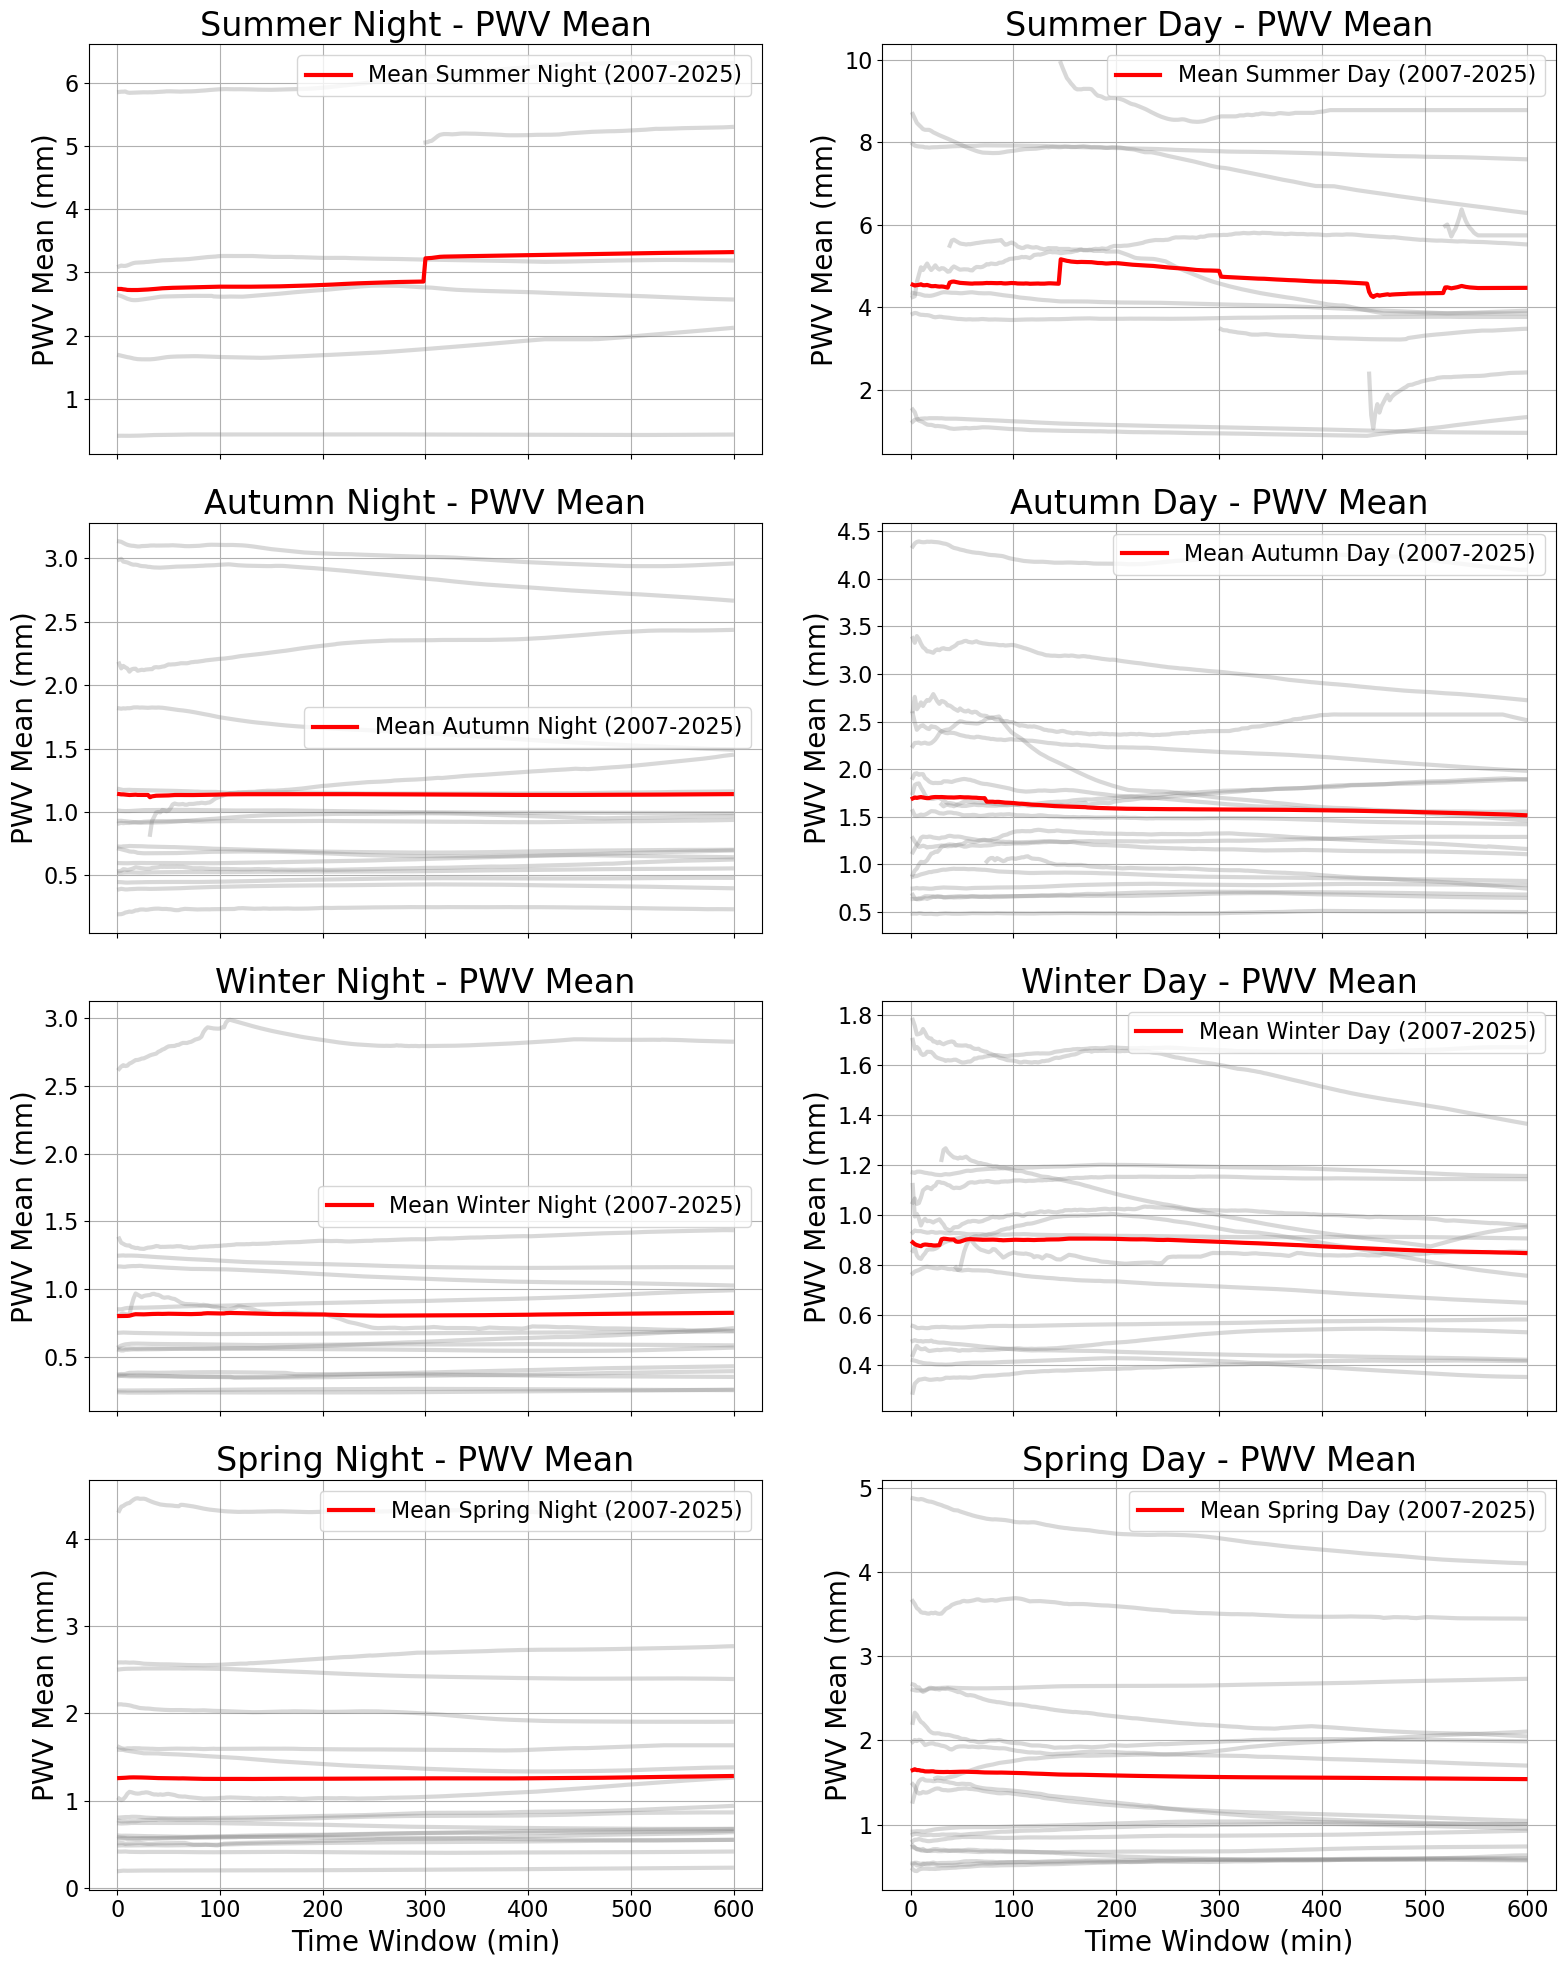

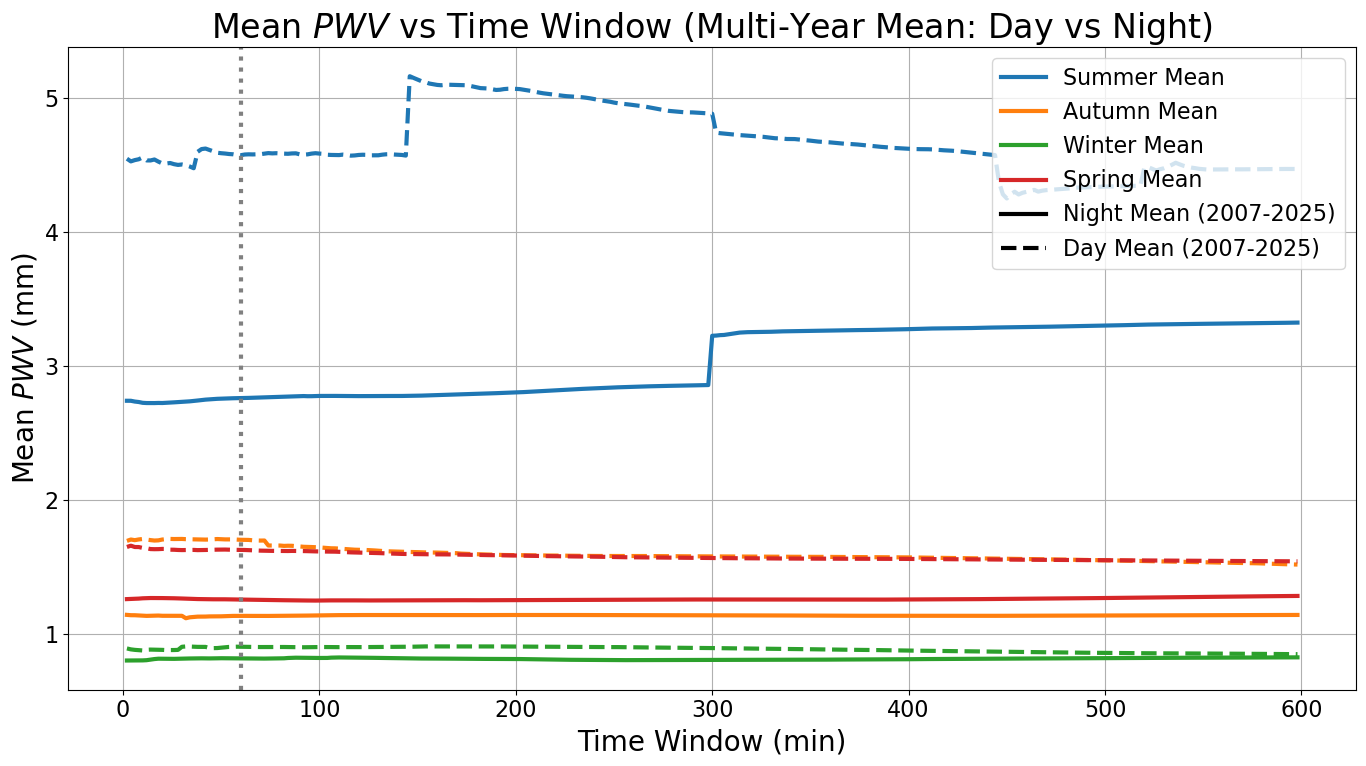

In [8]:
# Plot 1: PWV_mean individual plots (8 individual panels)
fig3, axes3 = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes3 = axes3.flatten()

for idx, (period_name, _) in enumerate(template_times.items()):
    ax = axes3[idx]
    df_period = multiyear_df[multiyear_df['period_name'] == period_name]
    
    # Plot individual years silently (gray, no legend)
    for y in years:
        df_year = df_period[df_period['year'] == y]
        if not df_year.empty:
            ax.plot(df_year['window (min)'], df_year['PWV_mean'], color='gray', alpha=0.3)
            
    # Plot the consolidated mean (highlighted with legend)
    mean_df = mean_results_by_period[period_name]
    label_name = f"Mean {period_name.replace('_', ' ').title()} (2007-2025)"
    ax.plot(mean_df['window (min)'], mean_df['PWV_mean'], color='red', linewidth=3, label=label_name)
    
    ax.set_title(f"{period_name.replace('_', ' ').title()} - PWV Mean")
    ax.set_ylabel(r"PWV Mean (mm)")
    if idx >= 6:
        ax.set_xlabel("Time Window (min)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot 2: PWV_mean summary plots (Day vs Night)
import matplotlib.lines as mlines

fig4, ax4 = plt.subplots(figsize=(14, 8))
seasons = ['summer', 'autumn', 'winter', 'spring']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
legend_handles4 = []

for i, season in enumerate(seasons):
    color = colors[i]
    
    # Plot Day Multi-Year Means (Dashed)
    name_day = f"{season}_day"
    mean_df_day = mean_results_by_period[name_day]
    ax4.plot(mean_df_day['window (min)'], mean_df_day['PWV_mean'], color=color, linestyle='--', linewidth=3)
    
    # Plot Night Multi-Year Means (Solid)
    name_night = f"{season}_night"
    mean_df_night = mean_results_by_period[name_night]
    ax4.plot(mean_df_night['window (min)'], mean_df_night['PWV_mean'], color=color, linestyle='-', linewidth=3)
    
    # Add season to custom legend
    legend_handles4.append(mlines.Line2D([], [], color=color, linewidth=3, label=f"{season.title()} Mean"))

# Add Day/Night styling to custom legend
legend_handles4.append(mlines.Line2D([], [], color='k', linestyle='-', linewidth=3, label='Night Mean (2007-2025)'))
legend_handles4.append(mlines.Line2D([], [], color='k', linestyle='--', linewidth=3, label='Day Mean (2007-2025)'))
ax4.axvline(60, color='gray', linestyle=':', linewidth=3)  # Vertical line at 60 minutes

ax4.set_title(r"Mean $PWV$ vs Time Window (Multi-Year Mean: Day vs Night)")
ax4.set_xlabel("Time Window (min)")
ax4.set_ylabel(r"Mean $PWV$ (mm)")
ax4.legend(handles=legend_handles4)
ax4.grid(True)

plt.tight_layout()
plt.show()

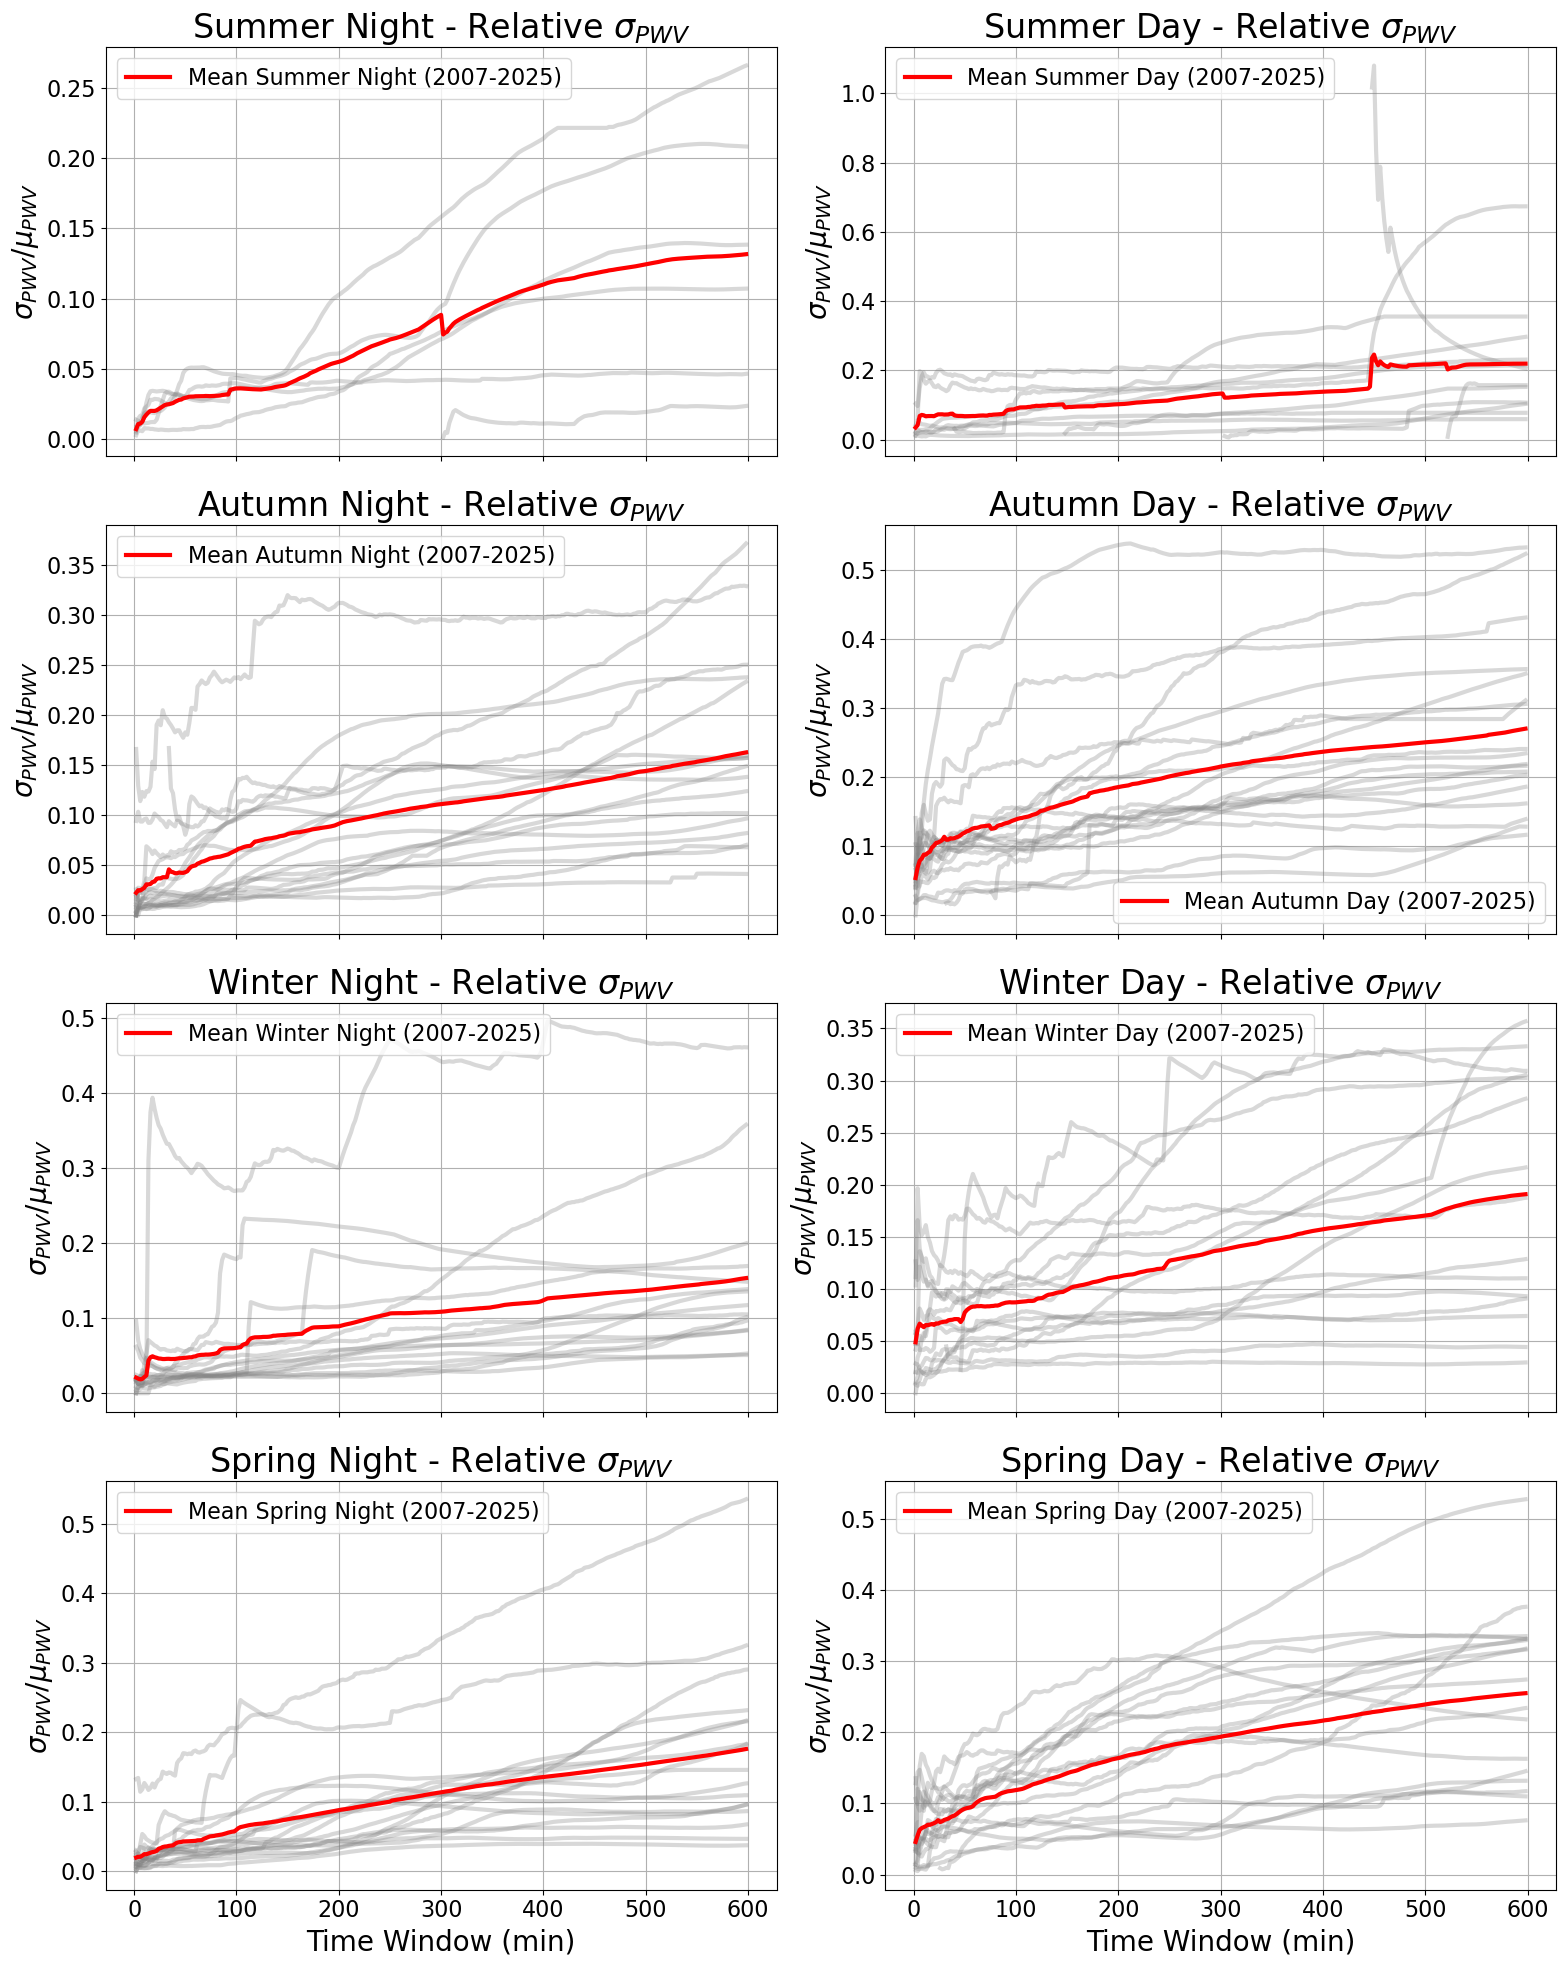

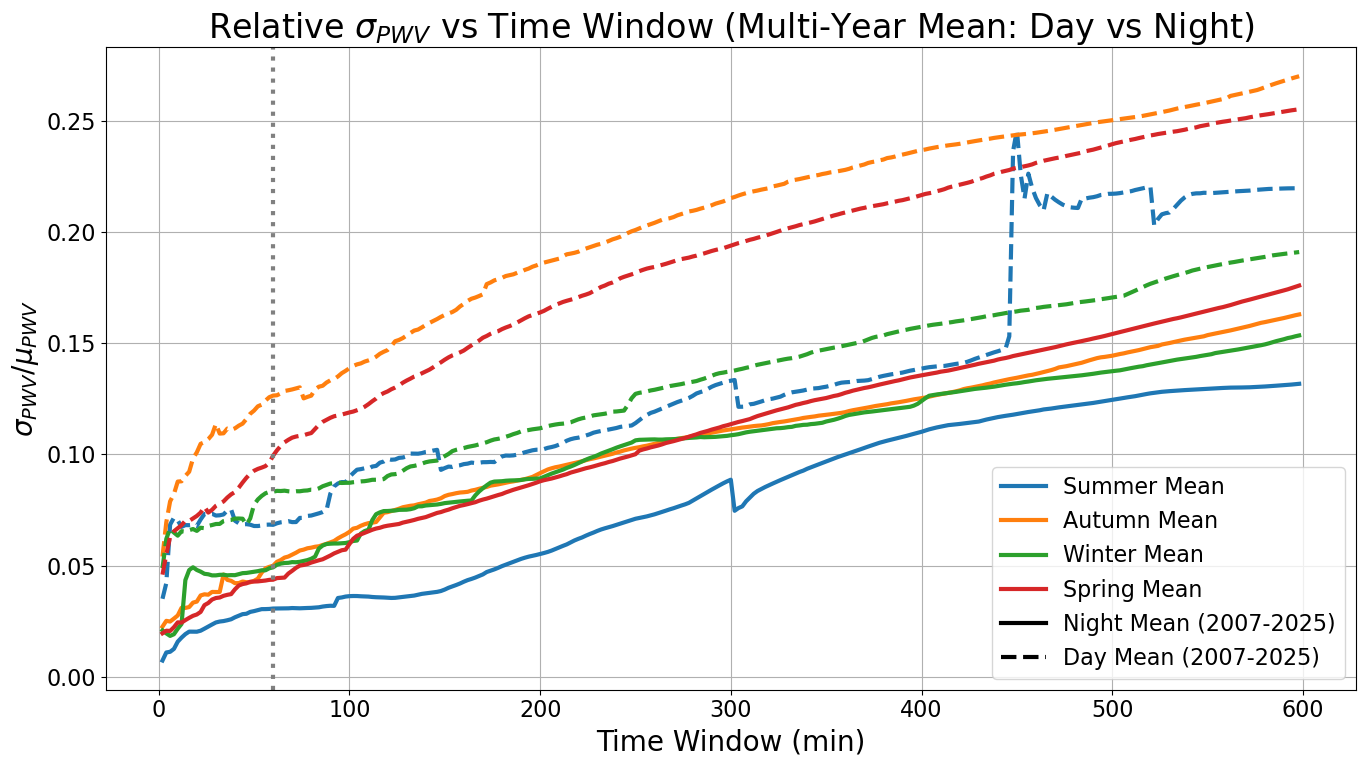

In [9]:
# Calculate relative sigma (sigma_PWV / mean_PWV)
multiyear_df['relative_sigma_PWV'] = multiyear_df['sigma_PWV'] / multiyear_df['PWV_mean']

# Update our mean_results dictionaries with the relative sigma means
for period_name in template_times.keys():
    df_period = multiyear_df[multiyear_df['period_name'] == period_name]
    mean_rel_sigma = df_period.groupby('window (min)')['relative_sigma_PWV'].mean().values
    mean_results_by_period[period_name]['relative_sigma_PWV'] = mean_rel_sigma

# Plot 1: Relative sigma PWV individual plots (8 individual panels)
fig5, axes5 = plt.subplots(4, 2, figsize=(16, 20), sharex=True)
axes5 = axes5.flatten()

for idx, (period_name, _) in enumerate(template_times.items()):
    ax = axes5[idx]
    df_period = multiyear_df[multiyear_df['period_name'] == period_name]
    
    # Plot individual years silently (gray, no legend)
    for y in years:
        df_year = df_period[df_period['year'] == y]
        if not df_year.empty:
            ax.plot(df_year['window (min)'], df_year['relative_sigma_PWV'], color='gray', alpha=0.3)
            
    # Plot the consolidated mean (highlighted with legend)
    mean_df = mean_results_by_period[period_name]
    label_name = f"Mean {period_name.replace('_', ' ').title()} (2007-2025)"
    ax.plot(mean_df['window (min)'], mean_df['relative_sigma_PWV'], color='red', linewidth=3, label=label_name)
    
    ax.set_title(f"{period_name.replace('_', ' ').title()} - Relative " + r"$\sigma_{PWV}$")
    ax.set_ylabel(r"$\sigma_{PWV} / \mu_{PWV}$")
    if idx >= 6:
        ax.set_xlabel("Time Window (min)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot 2: Relative sigma PWV summary plots (Day vs Night)
import matplotlib.lines as mlines

fig6, ax6 = plt.subplots(figsize=(14, 8))
seasons = ['summer', 'autumn', 'winter', 'spring']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
legend_handles6 = []

for i, season in enumerate(seasons):
    color = colors[i]
    
    # Plot Day Multi-Year Means (Dashed)
    name_day = f"{season}_day"
    mean_df_day = mean_results_by_period[name_day]
    ax6.plot(mean_df_day['window (min)'], mean_df_day['relative_sigma_PWV'], color=color, linestyle='--', linewidth=3)
    
    # Plot Night Multi-Year Means (Solid)
    name_night = f"{season}_night"
    mean_df_night = mean_results_by_period[name_night]
    ax6.plot(mean_df_night['window (min)'], mean_df_night['relative_sigma_PWV'], color=color, linestyle='-', linewidth=3)
    
    # Add season to custom legend
    legend_handles6.append(mlines.Line2D([], [], color=color, linewidth=3, label=f"{season.title()} Mean"))

# Add Day/Night styling to custom legend
legend_handles6.append(mlines.Line2D([], [], color='k', linestyle='-', linewidth=3, label='Night Mean (2007-2025)'))
legend_handles6.append(mlines.Line2D([], [], color='k', linestyle='--', linewidth=3, label='Day Mean (2007-2025)'))
ax6.axvline(60, color='gray', linestyle=':', linewidth=3)  # Vertical line at 60 minutes

ax6.set_title(r"Relative $\sigma_{PWV}$ vs Time Window (Multi-Year Mean: Day vs Night)")
ax6.set_xlabel("Time Window (min)")
ax6.set_ylabel(r"$\sigma_{PWV} / \mu_{PWV}$")
ax6.legend(handles=legend_handles6)
ax6.grid(True)

plt.tight_layout()
plt.show()